# EDA y Preparación de Datos - Formula 1 World Championship

Este notebook realiza el análisis exploratorio inicial y la preparación de los datos del dataset de Formula 1. 

La unidad de análisis elegida es **piloto-carrera**, donde cada fila representa la participación de un piloto en una carrera específica.

**Tablas utilizadas:**
* `results.csv`
* `races.csv`
* `drivers.csv`
* `constructors.csv`
* `status.csv`
* `driver_standings.csv`
* `circuits.csv`

*Nota: No se utiliza `qualifying.csv` debido a la alta cantidad de valores faltantes históricos y los constantes cambios de formato en la clasificación de la F1.*

**Objetivos de este notebook:**
1. Integrar las tablas relacionales.
2. Limpiar datos y tratar valores nulos/duplicados.
3. Generar nuevas variables (Feature Engineering).
4. Analizar distribuciones y relaciones entre variables (EDA).
5. Exportar la base procesada para aplicar PCA y Clustering en las siguientes etapas.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

DATA_RAW = "../data/raw"
DATA_PROCESSED = "../data/processed"
FIGURES_DIR = "../reports/figures/eda/"

## 1. Carga de datos y corrección de tipos

Se cargan las tablas necesarias y se realiza un reemplazo general de los valores `\N` (propios de la base Ergast) por valores nulos de NumPy para su correcto tratamiento. A continuación, se castean las variables numéricas y de fecha a sus tipos correspondientes antes de realizar la unión.

In [59]:
archivos = {
    "results": "results.csv",
    "races": "races.csv",
    "drivers": "drivers.csv",
    "constructors": "constructors.csv",
    "status": "status.csv",
    "driver_standings": "driver_standings.csv",
    "circuits": "circuits.csv"
}

tablas = {}

# Carga de datos y reemplazo de \N
for nombre, archivo in archivos.items():
    path = os.path.join(DATA_RAW, archivo)
    df = pd.read_csv(path)
    df = df.replace("\\N", np.nan)
    tablas[nombre] = df

results = tablas["results"]
races = tablas["races"]
drivers = tablas["drivers"]
constructors = tablas["constructors"]
status = tablas["status"]
driver_standings = tablas["driver_standings"]
circuits = tablas["circuits"]

# Corrección de tipos de datos
columnas_numericas_results = [
    "resultId", "raceId", "driverId", "constructorId", "grid", 
    "positionOrder", "points", "laps", "milliseconds", 
    "fastestLap", "rank", "fastestLapSpeed", "statusId"
]
for col in columnas_numericas_results:
    results[col] = pd.to_numeric(results[col], errors="coerce")

races["raceId"] = pd.to_numeric(races["raceId"], errors="coerce")
races["year"] = pd.to_numeric(races["year"], errors="coerce")
races["date"] = pd.to_datetime(races["date"], errors="coerce")

drivers["driverId"] = pd.to_numeric(drivers["driverId"], errors="coerce")
drivers["dob"] = pd.to_datetime(drivers["dob"], errors="coerce")
drivers["driver_name"] = (drivers["forename"].fillna("") + " " + drivers["surname"].fillna("")).str.strip()

constructors["constructorId"] = pd.to_numeric(constructors["constructorId"], errors="coerce")
status["statusId"] = pd.to_numeric(status["statusId"], errors="coerce")

col_num_standings = ["raceId", "driverId", "points", "position", "wins"]
for col in col_num_standings:
    driver_standings[col] = pd.to_numeric(driver_standings[col], errors="coerce")

## 2. Integración de tablas (Joins)

Se utiliza `results.csv` como tabla principal (`base`) ya que representa nuestro nivel de análisis (piloto en una carrera). Las demás tablas se añaden mediante `LEFT JOIN` para enriquecer la información sin alterar la cantidad de observaciones base.

In [60]:
# Renombrado de columnas para evitar conflictos en el merge
results_sel = results[["resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder", "points", "laps", "statusId"]].rename(columns={"points": "race_points"})
races_sel = races[["raceId", "year", "circuitId", "name", "date"]].rename(columns={"name": "race_name", "date": "race_date"})
drivers_sel = drivers[["driverId", "driver_name", "dob", "nationality"]].rename(columns={"nationality": "driver_nationality"})
constructors_sel = constructors[["constructorId", "name", "nationality"]].rename(columns={"name": "constructor_name", "nationality": "constructor_nationality"})
circuits_sel = circuits[["circuitId", "name", "country", "alt"]].rename(columns={"name": "circuit_name", "country": "circuit_country", "alt": "circuit_alt"})
driver_standings_sel = driver_standings[["raceId", "driverId", "points", "position", "wins"]].rename(columns={"points": "driver_championship_points", "position": "driver_championship_position", "wins": "driver_championship_wins"})

# Merges secuenciales
base = results_sel.copy()
base = base.merge(races_sel, on="raceId", how="left")
base = base.merge(drivers_sel, on="driverId", how="left")
base = base.merge(constructors_sel, on="constructorId", how="left")
base = base.merge(status[["statusId", "status"]], on="statusId", how="left")
base = base.merge(circuits_sel, on="circuitId", how="left")
base = base.merge(driver_standings_sel, on=["raceId", "driverId"], how="left")

## 3. Limpieza de datos y valores faltantes

Se realiza la eliminación de registros duplicados y filas que no contienen información obligatoria para el análisis (por ejemplo, identificadores clave). Las variables categóricas con valores nulos se rellenan con "Sin dato" para no perder registros útiles en los modelos posteriores.

In [61]:
df_model = base.copy()

# 1. Eliminar duplicados exactos y por ID de resultado
df_model = df_model.drop_duplicates()
if "resultId" in df_model.columns:
    df_model = df_model.drop_duplicates(subset=["resultId"], keep="first")

# 2. Eliminar combinaciones duplicadas de carrera y piloto
df_model = df_model.drop_duplicates(subset=["raceId", "driverId"], keep="first")

# 3. Eliminar filas sin las columnas indispensables
columnas_obligatorias = ["raceId", "driverId", "constructorId", "year", "positionOrder", "grid"]
df_model = df_model.dropna(subset=columnas_obligatorias)

# 4. Tratamiento de nulos en variables categóricas
columnas_categoricas_con_nulos = ["status", "circuit_name", "circuit_country", "driver_nationality", "constructor_nationality"]
for col in columnas_categoricas_con_nulos:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna("Sin dato")

## 4. Recorte de la base
Se fija en el proyecto un máximo de 10.000 observaciones para agilizar los tiempos de procesamiento en los algoritmos de clustering. 
En lugar de tomar una muestra aleatoria de toda la historia, primero se filtra desde el año 2000 en adelante. Esto asegura que el análisis se centre en la "era moderna" de la F1, donde los sistemas de puntuación, la tecnología y las reglas son más homogéneos. Finalmente, si la cantidad de filas sigue superando el límite, se toma una muestra aleatoria fijando una semilla para asegurar la reproducibilidad.

In [62]:
ANIO_MINIMO = 2000
LIMITE_FILAS = 10000

df_model = df_model[df_model["year"] >= ANIO_MINIMO].copy()

if df_model.shape[0] > LIMITE_FILAS:
    df_model = df_model.sample(n=LIMITE_FILAS, random_state=42).copy()

print(f"Filas finales para el análisis: {df_model.shape[0]}")
print(f"Rango de años: {df_model['year'].min()} - {df_model['year'].max()}")

Filas finales para el análisis: 10000
Rango de años: 2000 - 2024


## 5. Creación de variables derivadas

En esta sección se construyen nuevas variables que facilitan la interpretación del análisis.

Se calculan:

- Edad del piloto al momento de la carrera.
- Década de la carrera.
- Grupo de resultado final.
- Grupo de largada.
- Indicador de podio.
- Indicador de top 10.
- Indicador de victoria.
- Grupo general del estado final de la carrera.
- Proporción de vueltas completadas respecto del máximo de vueltas de cada carrera.

Estas variables permiten transformar información técnica del dataset en categorías más interpretables para el análisis exploratorio, el PCA y el clustering.

In [63]:
# Edad del piloto en años al momento de la carrera
df_model["driver_age"] = (df_model["race_date"] - df_model["dob"]).dt.days / 365.25

# Agrupación de resultados
def asignar_resultado_grupo(pos):
    if pd.isna(pos): return np.nan
    if pos == 1: return "Ganador"
    if pos <= 3: return "Podio"
    if pos <= 10: return "Top 10"
    return "Fuera del top 10"

df_model["resultado_grupo"] = df_model["positionOrder"].apply(asignar_resultado_grupo)

# Agrupación de largada
def asignar_largada_grupo(grid):
    if pd.isna(grid): return np.nan
    if grid <= 0: return "Pit lane"
    if grid == 1: return "Pole"
    if grid <= 5: return "Top 5"
    if grid <= 10: return "Top 10"
    return "Fondo"

df_model["largada_grupo"] = df_model["grid"].apply(asignar_largada_grupo)

# Estandarización de vueltas: proporción completada respecto al máximo de esa carrera
df_model["laps_max_race"] = df_model.groupby("raceId")["laps"].transform("max")
df_model["laps_pct"] = df_model["laps"] / df_model["laps_max_race"]

# Selección final y orden de columnas
cols_ordenadas = [
    "raceId", "driverId", "constructorId", "year", "race_name", "circuit_name", "circuit_country", 
    "driver_name", "driver_age", "driver_nationality", "constructor_name", 
    "grid", "largada_grupo", "positionOrder", "resultado_grupo", "race_points", 
    "laps", "laps_pct", "status", "driver_championship_points", 
    "driver_championship_position", "driver_championship_wins", "circuit_alt"
]
df_model = df_model[cols_ordenadas]

## 6. Análisis Exploratorio y Selección para PCA

Se realiza una exploración visual para entender las distribuciones y las relaciones lineales. 
La selección de variables para el PCA descarta los identificadores (IDs) ya que carecen de significado analítico. Nos concentramos en variables deportivas numéricas continuas o discretas (puntos, posiciones, edades).

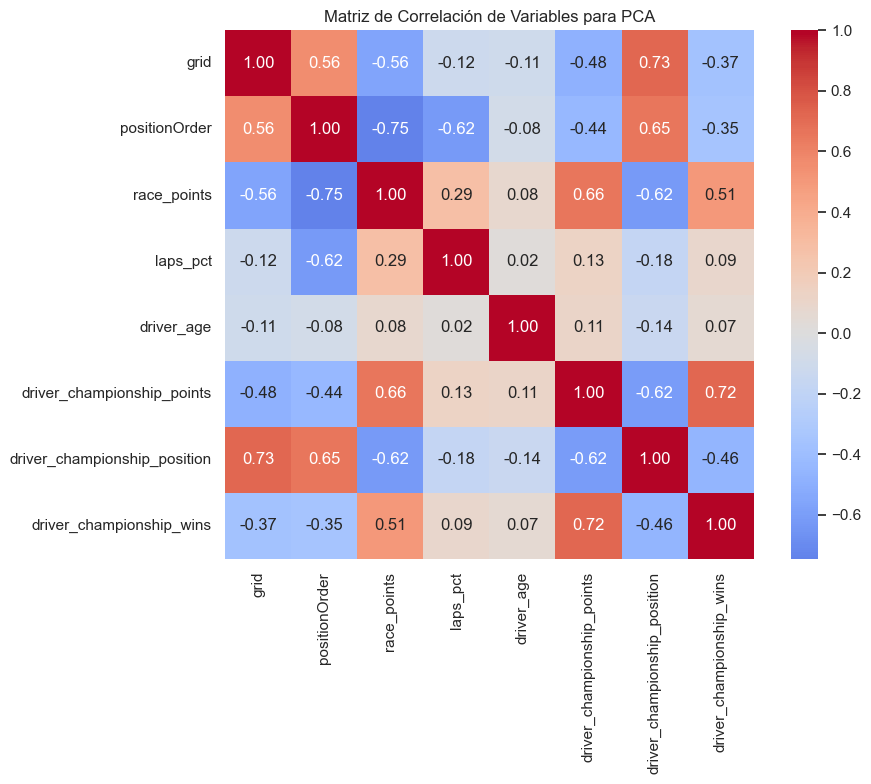

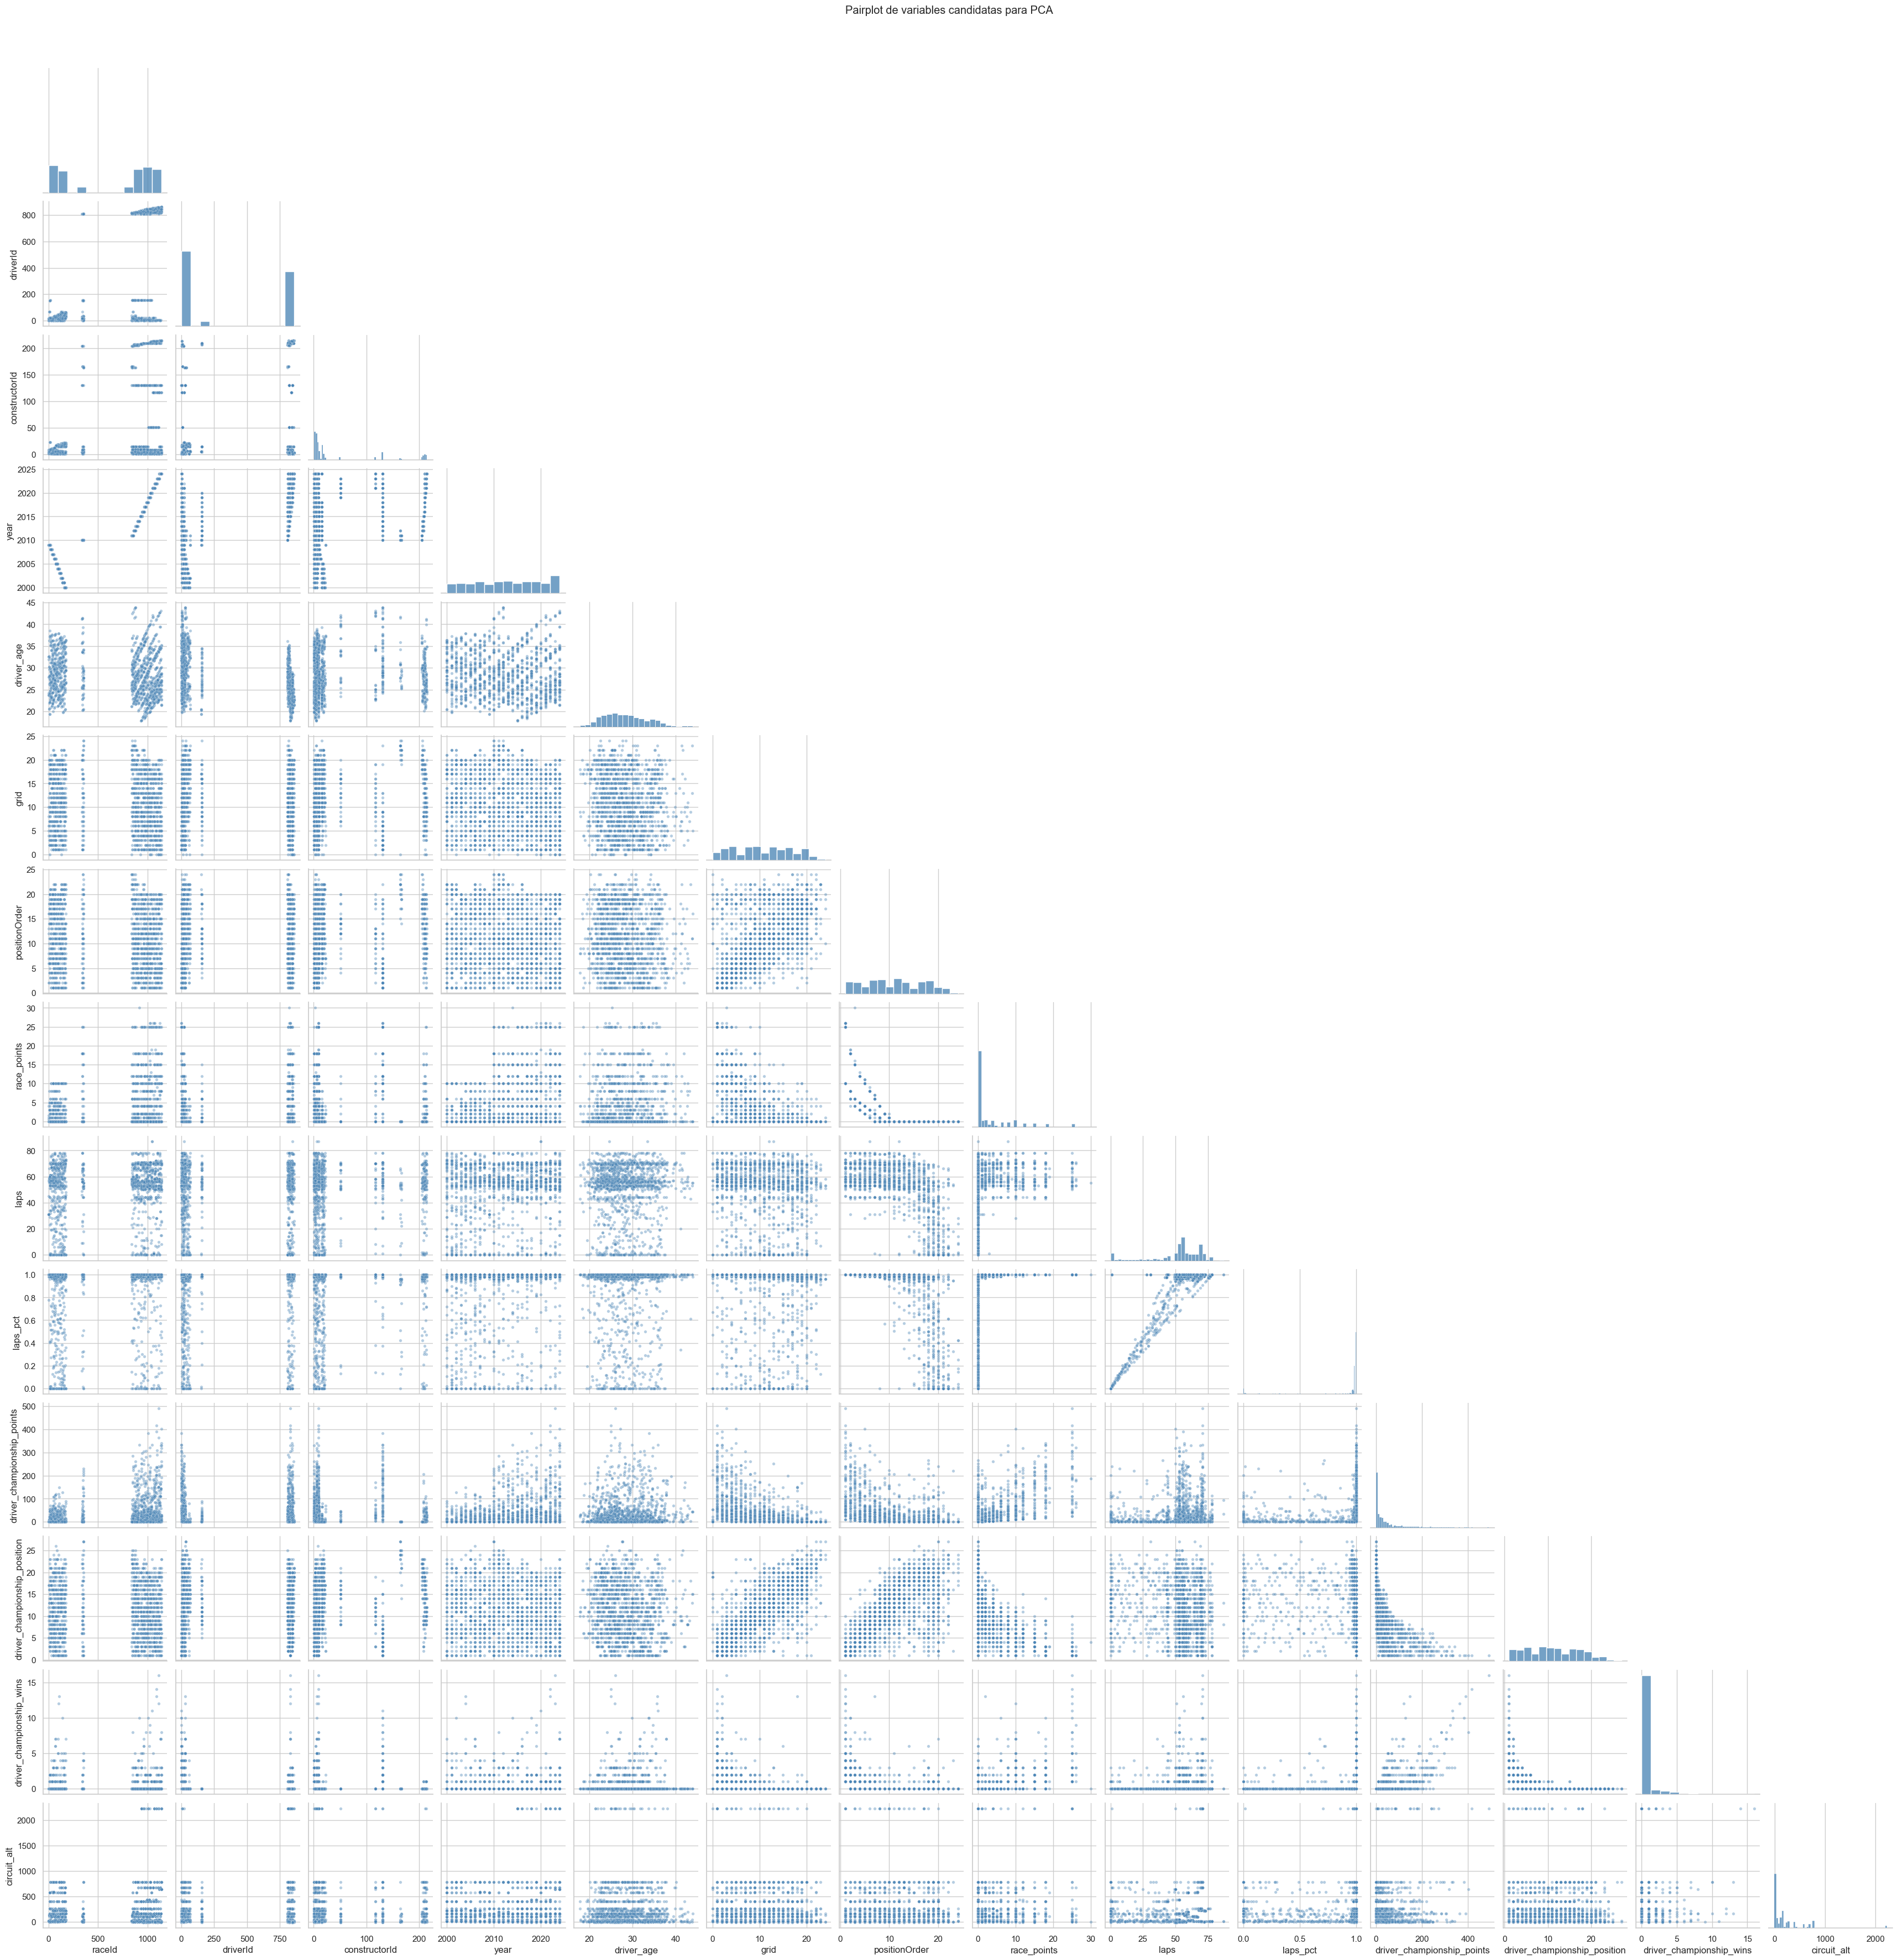

In [64]:
# Variables numéricas válidas para PCA
variables_pca = [
    "grid", "positionOrder", "race_points", "laps_pct", "driver_age", 
    "driver_championship_points", "driver_championship_position", 
    "driver_championship_wins"
]

# Matriz de Correlación
df_corr = df_model[variables_pca].dropna()
matriz_correlacion = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de Correlación de Variables para PCA")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "matriz_correlacion_pca.png"))
plt.show()

TAMANIO_MUESTRA = 1500

if len(df_model) > TAMANIO_MUESTRA:
    df_pairplot = df_model.sample(n=TAMANIO_MUESTRA, random_state=42)
else:
    df_pairplot = df_model.copy()

pairplot = sns.pairplot(
    df_pairplot,
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.4, "s": 15, "color": "steelblue"},
    diag_kws={"color": "steelblue"}
)
pairplot.fig.suptitle("Pairplot de variables candidatas para PCA", y=1.02)
pairplot.savefig(os.path.join(FIGURES_DIR, "pairplot_pca.png"), dpi=300, bbox_inches="tight")
plt.show()

## 7. Exportación de los datos procesados

Los datos limpios, transformados y recortados se guardan en el directorio `processed`. El siguiente notebook, encargado de la reducción de dimensionalidad (PCA), deberá cargar directamente este archivo, asegurando la continuidad del flujo de trabajo y la limpieza del entorno.

In [ ]:
archivo_salida = os.path.join(DATA_PROCESSED, "formula1_base.csv")
df_model.to_csv(archivo_salida, index=False)

print(f"Base lista y exportada con éxito en: {archivo_salida}")
print(f"Dimensiones finales: {df_model.shape}")

Base lista y exportada con éxito en: ../data/processed/formula1_base_trabajo.csv
Dimensiones finales: (10000, 23)
